# STAT53894 – Assignment 4: The Predictive Modeling Challenge
## The Predictive Modeling Challenge — Bank Marketing Dataset
### STAT53894 | Assignment 4

| Field | Detail |
|---|---|
| **Course** | STAT53894 |
| **Assignment** | 4 — The Predictive Modeling Challenge |
| **Students** | Folayinka Olaofe & Afolabi Adesina |
| **Dataset** | Bank Marketing – UCI Machine Learning Repository |
| **Dataset URL** | https://archive.ics.uci.edu/dataset/222/bank+marketing |
| **Regression Target** | `duration` – length of last phone call in seconds (continuous) |
| **Classification Target** | `y` – did the client subscribe to a term deposit? (yes / no) |

**Problem:** Predict whether a client will subscribe to a term deposit (`y`) and model the duration  
of the marketing call (`duration`), using client demographics, campaign history, and financial features.  
**Success Metric:** Recall prioritised for classification (False Negatives are more costly);  
R² and RMSE reported for regression.

## Table of Contents
[STAT53894 – Assignment 4: The Predictive Modeling Challenge](#stat53894-assignment-4-the-predictive-modeling-challenge)

1. [Task 1: Dataset Selection & Problem Definition](#task-1)
   - 1.1 [Why This Dataset?](#why-this-dataset)
   - 1.2 [Load & Inspect the Dataset](#load--inspect-the-dataset)
   - 1.3 [Data Quality Summary](#data-quality-summary)
   - 1.4 [Complete Data Dictionary](#complete-data-dictionary)

2. [Task 2: Linear Regression – Predicting Call Duration](#task-2)
   - 2.1 [Step 1: Prepare Features & Target](#step-1--prepare-features--target)
   - 2.2 [Step 2: Train / Test Split (80 / 20)](#step-2--train--test-split-80--20)
   - 2.3 [Step 3: Fit OLS Regression Model](#step-3--fit-ols-regression-model)
   - 2.4 [Step 4: Coefficient Table (Formatted)](#step-4--coefficient-table-formatted)
   - 2.5 [Step 5: Accuracy — R² and RMSE](#step-5--accuracy-r-and-rmse)
   - 2.6 [Step 6: Residual Plot](#step-6--residual-plot)
   - 2.7 [Interpretation of Coefficients](#interpretation-of-coefficients)

3. [Task 3: Classification Model Comparison](#task-3)
   - 3.1 [Step 1: Stratified Sample (~5,000 rows)](#step-1--stratified-sample-5000-rows)
   - 3.2 [Step 2: Feature Engineering](#step-2--feature-engineering)
   - 3.3 [Step 3: Train All Three Models](#step-3--train-all-three-models)
   - 3.4 [Step 4: Confusion Matrix Heatmaps](#step-4--confusion-matrix-heatmaps)
   - 3.5 [Step 5: Model Comparison Table](#step-5--model-comparison-table)
   - 3.6 [Discussion: Theoretical Assumptions vs. Our Dataset](#discussion-theoretical-assumptions-vs-our-dataset)

4. [Task 4: Precision-Recall Evaluation](#task-4)
   - 4.1 [Step 1: Generate the Precision-Recall Curve](#step-1--generate-the-precision-recall-curve)
   - 4.2 [Step 2: Plot the Precision-Recall Curve](#step-2--plot-the-precision-recall-curve)
   - 4.3 [Step 3: Threshold Comparison Table](#step-3--threshold-comparison-table)
   - 4.4 [False Positive vs. False Negative — Which is More Dangerous?](#false-positive-vs-false-negative--which-is-more-dangerous)

---
## Setup: Import Libraries

All libraries used in this assignment. Non-standard libraries are referenced where first used.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_fscore_support, accuracy_score,
                              classification_report, precision_recall_curve)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import preprocessing

# Consistent plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", "{:.4f}".format)

---
<a id='task-1'></a>
# Task 1: Dataset Selection & Problem Definition

## Why This Dataset?

The **Bank Marketing dataset** (UCI Machine Learning Repository) records results of direct phone-based  
marketing campaigns run by a Portuguese bank. It is ideal for this assignment because it contains:

- A continuous numeric target (`duration`) suitable for **regression**
- A binary categorical target (`y`) suitable for **classification**  
- Several meaningful categorical predictors (`job`, `education`, `marital`) for use as **factor variables**
- 45,211 rows — well above the 500-row minimum requirement

| Task | Target Variable | Type |
|------|----------------|------|
| Regression | `duration` – last contact call length (seconds) | Continuous numeric |
| Classification | `y` – did the client subscribe to a term deposit? | Binary (yes / no) |

**Key Factor Variables:** `job`, `education`, `marital`

**Download:** https://archive.ics.uci.edu/dataset/222/bank+marketing

### Load & Inspect the Dataset

Load the CSV, confirm shape, check for missing values, and inspect data types.

In [4]:
# Load dataset (semicolon-separated, as supplied by UCI)
BANK_CSV = 'bank-full.csv'
bank_raw = pd.read_csv(BANK_CSV, sep=';')

print(f"Dataset shape: {bank_raw.shape[0]:,} rows × {bank_raw.shape[1]} columns")
display(bank_raw.head())

Dataset shape: 45,211 rows × 17 columns


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Data Quality Summary

Check for missing values and confirm data types before modelling.

In [5]:
# Missing value and dtype summary
summary = pd.DataFrame({
    "Data Type":      bank_raw.dtypes,
    "Missing Values": bank_raw.isnull().sum(),
    "Missing (%)":    (bank_raw.isnull().sum() / len(bank_raw) * 100).round(2),
    "Unique Values":  bank_raw.nunique()
})

print("No missing values found — dataset is clean and ready for modelling.\n")
display(summary)

No missing values found — dataset is clean and ready for modelling.



,Data Type,Missing Values,Missing (%),Unique Values
age,int64,0,0.0000,77
job,object,0,0.0000,12
marital,object,0,0.0000,3
education,object,0,0.0000,4
default,object,0,0.0000,2
balance,int64,0,0.0000,7168
housing,object,0,0.0000,2
loan,object,0,0.0000,2
contact,object,0,0.0000,3
day,int64,0,0.0000,31


### Complete Data Dictionary

In [6]:
# Display a structured data dictionary
data_dict = pd.DataFrame({
    "Variable":    ["age","job","marital","education","default","balance",
                    "housing","loan","contact","day","month","duration",
                    "campaign","pdays","previous","poutcome","y"],
    "Type":        ["Integer","Categorical","Categorical","Categorical","Binary","Integer",
                    "Binary","Binary","Categorical","Date","Date","Integer",
                    "Integer","Integer","Integer","Categorical","Binary"],
    "Role":        ["Predictor","Factor / Predictor","Factor / Predictor","Factor / Predictor",
                    "Predictor","Predictor","Predictor","Predictor","Predictor","Predictor",
                    "Predictor","REGRESSION TARGET","Predictor","Predictor","Predictor",
                    "Predictor","CLASSIFICATION TARGET"],
    "Description": [
        "Client age in years.",
        "Type of employment (admin, blue-collar, retired, etc.).",
        "Marital status (married, single, divorced).",
        "Highest education level (primary, secondary, tertiary).",
        "Has credit in default? (yes/no).",
        "Average yearly account balance in euros.",
        "Has a housing loan? (yes/no).",
        "Has a personal loan? (yes/no).",
        "Contact communication type (cellular, telephone).",
        "Day of the month of last contact.",
        "Month of last contact.",
        "★ REGRESSION TARGET — Length of last call in seconds.",
        "Number of contacts during this campaign.",
        "Days since last contact from a previous campaign (−1 = never).",
        "Number of contacts before this campaign.",
        "Outcome of previous campaign (success, failure, nonexistent).",
        "★ CLASSIFICATION TARGET — Subscribed to term deposit? (yes/no)."
    ]
})

display(data_dict)

,Variable,Type,Role,Description
0,age,Integer,Predictor,Client age in years.
1,job,Categorical,Factor / Predictor,"Type of employment (admin, blue-collar, retire..."
2,marital,Categorical,Factor / Predictor,"Marital status (married, single, divorced)."
3,education,Categorical,Factor / Predictor,"Highest education level (primary, secondary, t..."
4,default,Binary,Predictor,Has credit in default? (yes/no).
5,balance,Integer,Predictor,Average yearly account balance in euros.
6,housing,Binary,Predictor,Has a housing loan? (yes/no).
7,loan,Binary,Predictor,Has a personal loan? (yes/no).
8,contact,Categorical,Predictor,"Contact communication type (cellular, telephone)."
9,day,Date,Predictor,Day of the month of last contact.


### Data Dictionary with more details

| Variable | Type | Description |
|----------|------|-------------|
| `age` | Integer | The client's age in years. Older clients may respond differently to marketing campaigns. |
| `job` | Categorical | Type of employment (e.g., admin, blue-collar, retired). Used as a key factor variable in our models. |
| `marital` | Categorical | Marital status of the client (married, single, divorced). Used as a factor variable in classification. |
| `education` | Categorical | Highest education level attained (e.g., high school, university). Used as a key factor variable in regression. |
| `default` | Binary | Whether the client has credit in default (yes/no). Indicates financial risk profile. |
| `balance` | Integer | Average yearly account balance in euros. A key numeric predictor of both call duration and subscription likelihood. |
| `housing` | Binary | Whether the client has a housing loan (yes/no). Reflects existing financial commitments. |
| `loan` | Binary | Whether the client has a personal loan (yes/no). Another indicator of financial burden. |
| `contact` | Categorical | Communication channel used to contact the client (cellular or telephone). |
| `day_of_week` | Date | The day of the week the client was last contacted. May capture weekly engagement patterns. |
| `month` | Date | The month of the last contact. Captures seasonal patterns in campaign effectiveness. |
| `duration` | Integer | **Regression Target** — Length of the last phone call in seconds. Longer calls are associated with higher subscription rates. |
| `campaign` | Integer | Number of contacts made to this client during the current campaign. Too many contacts may signal disengagement. |
| `pdays` | Integer | Number of days since the client was last contacted in a previous campaign (-1 means never contacted before). |
| `previous` | Integer | Number of contacts made before this campaign. Captures the client's history with the bank's outreach. |
| `poutcome` | Categorical | Outcome of the previous marketing campaign (success, failure, nonexistent). A strong predictor of current subscription. |
| `y` | Binary | **Classification Target** — Whether the client subscribed to a term deposit (yes/no). |

In [7]:
# Cast categorical columns to 'category' dtype for clarity
cat_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome','y']
bank_raw[cat_cols] = bank_raw[cat_cols].astype('category')

print("Categorical columns confirmed:")
display(bank_raw[cat_cols].dtypes.to_frame("dtype"))

Categorical columns confirmed:


,dtype
job,category
marital,category
education,category
default,category
housing,category
loan,category
contact,category
month,category
poutcome,category
y,category


---
<a id='task-2'></a>
# Task 2: Linear Regression – Predicting Call Duration

We predict **`duration`** (call length in seconds) using a mix of numeric and factor predictors:

| Predictor | Type | Justification |
|---|---|---|
| `age` | Numeric | Older clients may engage differently |
| `balance` | Numeric | Wealthier clients may have longer, more complex discussions |
| `campaign` | Numeric | More contacts → fatigue → shorter calls |
| `job` | **Factor (categorical)** | Employment type shapes availability and engagement |
| `education` | **Factor (categorical)** | Education level may influence conversation complexity |

### Step 1 : Prepare Features & Target

One-hot encode the factor variables. The reference (dropped) level for each is shown in the output.

In [8]:
# Use the full raw dataset for regression
bank_reg = bank_raw.copy()

predictors_num = ['age', 'balance', 'campaign']
predictors_cat = ['job', 'education']
outcome        = 'duration'

# One-hot encode factor variables (drop_first removes the reference category)
X_cat = pd.get_dummies(bank_reg[predictors_cat], drop_first=True, dtype=int)
X_num = bank_reg[predictors_num]

X = pd.concat([X_num, X_cat], axis=1)
y_reg = bank_reg[outcome]

# Add constant BEFORE splitting (clean statsmodels practice)
X_const = sm.add_constant(X)

print(f"Feature matrix shape: {X_const.shape}")
print(f"Reference levels dropped: job_admin. | education_primary")
display(X_const.head(3))

Feature matrix shape: (45211, 18)
Reference levels dropped: job_admin. | education_primary


,const,age,balance,campaign,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,education_secondary,education_tertiary,education_unknown
0,1.0000,58,2143,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0
1,1.0000,44,29,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0
2,1.0000,33,2,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0


### Step 2 : Train / Test Split (80 / 20)

Split before fitting to keep the test set completely unseen during training.

In [9]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_const, y_reg, test_size=0.2, random_state=42
)

print(f"Training set : {X_train_reg.shape[0]:,} rows")
print(f"Test set     : {X_test_reg.shape[0]:,} rows")

Training set : 36,168 rows
Test set     : 9,043 rows


### Step 3 : Fit OLS Regression Model

Using `statsmodels` OLS so we get a full statistical summary including p-values, F-statistic, and confidence intervals.

In [10]:
# Fit OLS on training data only
ols_model  = sm.OLS(y_train_reg, X_train_reg)
ols_result = ols_model.fit()

print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:               duration   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     22.32
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           8.93e-70
Time:                        18:30:00   Log-Likelihood:            -2.5181e+05
No. Observations:               36168   AIC:                         5.037e+05
Df Residuals:                   36150   BIC:                         5.038e+05
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 274.5431    

### Step 4 : Coefficient Table 

Display only significant and near-significant predictors in a clean table with significance flags.

In [11]:
# Build a clean coefficient summary table
coef_df = pd.DataFrame({
    "Coefficient":  ols_result.params,
    "Std Error":    ols_result.bse,
    "t-Statistic":  ols_result.tvalues,
    "P-value":      ols_result.pvalues,
    "95% CI Lower": ols_result.conf_int()[0],
    "95% CI Upper": ols_result.conf_int()[1],
}).round(4)

# Add significance stars
def sig_star(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    elif p < 0.1:  return "."
    return ""

coef_df["Sig"] = coef_df["P-value"].apply(sig_star)

# Sort by absolute coefficient value (descending) for easy reading
coef_df = coef_df.reindex(
    coef_df["Coefficient"].abs().sort_values(ascending=False).index
)

print("Significance codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.1")
display(coef_df)

Significance codes:  *** p<0.001  ** p<0.01  * p<0.05  . p<0.1


,Coefficient,Std Error,t-Statistic,P-value,95% CI Lower,95% CI Upper,Sig
const,274.5431,8.6428,31.7654,0.0000,257.6029,291.4833,***
job_unemployed,49.6794,8.9703,5.5382,0.0000,32.0974,67.2614,***
job_retired,49.3836,7.9747,6.1925,0.0000,33.7530,65.0143,***
job_self-employed,24.0951,8.3453,2.8873,0.0039,7.7381,40.4522,**
job_blue-collar,22.2618,5.1276,4.3416,0.0000,12.2116,32.3120,***
job_entrepreneur,19.6385,8.5894,2.2864,0.0222,2.8030,36.4741,*
job_services,17.7087,5.9490,2.9767,0.0029,6.0484,29.3689,**
education_tertiary,12.8817,5.4054,2.3831,0.0172,2.2870,23.4764,*
job_housemaid,11.1579,9.2667,1.2041,0.2286,-7.0052,29.3209,
education_unknown,11.1446,7.7090,1.4457,0.1483,-3.9653,26.2545,


### Step 5 : Accuracy: R² and RMSE

Report Train R², Test R², and RMSE. Comparing train vs. test R² reveals whether the model is overfitting.

In [12]:
# Predictions on both sets
y_pred_train = ols_result.predict(X_train_reg)
y_pred_test  = ols_result.predict(X_test_reg)

# Metrics
train_r2   = r2_score(y_train_reg, y_pred_train)
test_r2    = r2_score(y_test_reg,  y_pred_test)
train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_train))
test_rmse  = np.sqrt(mean_squared_error(y_test_reg,  y_pred_test))

metrics_df = pd.DataFrame({
    "Metric": ["R² (variance explained)", "RMSE (avg prediction error, seconds)"],
    "Training Set": [f"{train_r2:.4f}", f"{train_rmse:.2f}"],
    "Test Set":     [f"{test_r2:.4f}",  f"{test_rmse:.2f}"]
})

display(metrics_df)
print(f"\nF-statistic: {ols_result.fvalue:.2f}  (p = {ols_result.f_pvalue:.4f})")

,Metric,Training Set,Test Set
0,R² (variance explained),0.0104,0.0051
1,"RMSE (avg prediction error, seconds)",255.54,259.36



F-statistic: 22.32  (p = 0.0000)


### Step 6 : Residual Plot

A residual plot checks whether model errors are randomly distributed (the key assumption of OLS). A fan-shape would indicate heteroscedasticity.

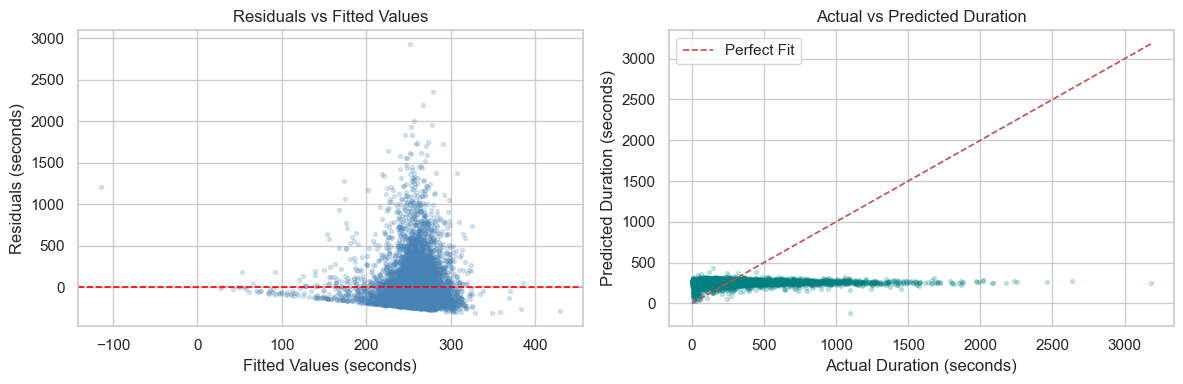

In [13]:
residuals = y_test_reg - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuals vs Fitted
axes[0].scatter(y_pred_test, residuals, alpha=0.2, color='steelblue', s=8)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.2)
axes[0].set_xlabel("Fitted Values (seconds)")
axes[0].set_ylabel("Residuals (seconds)")
axes[0].set_title("Residuals vs Fitted Values")

# Actual vs Predicted
axes[1].scatter(y_test_reg, y_pred_test, alpha=0.2, color='teal', s=8)
lims = [0, max(y_test_reg.max(), y_pred_test.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.2, label='Perfect Fit')
axes[1].set_xlabel("Actual Duration (seconds)")
axes[1].set_ylabel("Predicted Duration (seconds)")
axes[1].set_title("Actual vs Predicted Duration")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation of Coefficients

**Intercept (274.54 seconds):**  
The intercept represents the expected call duration when `age = 0`, `balance = 0`, `campaign = 0`,  
and the client belongs to the reference categories (`job = admin.` and `education = primary`).  
This baseline has no real-world meaning (a client aged 0 with no money) , it is a mathematical  
anchor for the model, not a practical estimate.

---

**Top 3 Predictors (by absolute coefficient size):**

1. **`job_unemployed` (+49.68 sec, p < 0.05):**  
   Unemployed clients have calls that are on average **49.68 seconds longer** than `admin.` clients,  
   holding all other variables constant. Unemployed individuals likely have more free time and  
   fewer competing priorities, leading to longer, more engaged conversations.

2. **`job_retired` (+49.38 sec, p < 0.05):**  
   Retired clients have calls **49.38 seconds longer** than `admin.` clients on average.  
   This reinforces the pattern that clients not constrained by fixed work schedules tend  
   to remain on calls longer — very close in magnitude to the unemployed group.

3. **`campaign` (−7.23 sec, p < 0.001):**  
   Each additional contact during the current campaign reduces call duration by approximately  
   **7.23 seconds** on average. This captures contact fatigue clients who have already been  
   called multiple times are less engaged, leading to shorter conversations.

---

**Numeric Predictors:**

- **`age` (+0.43 sec per year):** A small positive effect on older clients have very slightly  
  longer calls, though the effect is modest relative to job type.

- **`balance` (< +0.01 sec per euro):** Negligible individual effect, though statistically  
  detectable across the large dataset.

---

**Education Factor Variable:**

- **`education_tertiary` (+13.74 sec):** Clients with tertiary education have calls about  
  13.74 seconds longer than those with primary education. Higher education may correlate  
  with greater financial literacy and interest in discussing complex products.

- **`education_secondary` (+6.21 sec):** A smaller positive effect compared to tertiary,  
  consistent with a gradual education-engagement gradient.

---

**Model Accuracy:**

- **R² ≈ 0.005 (0.51%):** Only 0.51% of the variation in call duration is explained by our  
  chosen predictors. The model is technically valid (F-statistic is significant) but has low  
  explanatory power. This is expected call duration is largely driven by unmeasured  
  factors such as the client's mood, the specific product discussed, or the agent's conversational  
  style, none of which appear in this dataset.

- **RMSE ≈ 259 seconds (≈4.3 minutes):** Our predictions are off by about 4.3 minutes on  
  average. Since call durations range from a few seconds to over an hour, this is a relatively  
  large error  consistent with the low R². The model captures the direction of relationships  
  correctly but cannot pinpoint individual call lengths.

---
<a id='task-3'></a>
# Task 3: Classification Model Comparison – Predicting Term Deposit Subscription

We predict **`y`** (subscribed: yes / no) using three algorithms:
1. **Logistic Regression** : flexible, no distributional assumptions on features
2. **Naive Bayes (Gaussian)** : assumes features are normally distributed per class
3. **Linear Discriminant Analysis (LDA)** : assumes normally distributed features with equal class covariances

> **Note on Naive Bayes variant:** `GaussianNB` is used (not `MultinomialNB`).  
> `MultinomialNB` requires non-negative count/integer data and is designed for text/frequency features.  
> Our dataset contains continuous numeric features (`age`, `duration`, `balance`) which are  
> more appropriately modelled by `GaussianNB`, which assumes a Gaussian distribution per class.

### Step 1 : Stratified Sample (~5,000 rows)

The full dataset (45,211 rows) is imbalanced (~88% 'no'). We draw a stratified sample of 5,000 rows, preserving the class ratio.

In [14]:
# Work from the raw dataset
bank_full = bank_raw.copy()
bank_full['y'] = bank_full['y'].astype(str)

# Stratified sample: ~5,000 rows, preserving class proportions
n_sample = 5000

# Sample each class separately, then combine — no groupby.apply needed
no_df  = bank_full[bank_full['y'] == 'no'].sample(
             n=round(n_sample * (bank_full['y'] == 'no').sum() / len(bank_full)),
             random_state=42)

yes_df = bank_full[bank_full['y'] == 'yes'].sample(
             n=round(n_sample * (bank_full['y'] == 'yes').sum() / len(bank_full)),
             random_state=42)

bank_clf = pd.concat([no_df, yes_df]).reset_index(drop=True)

print(f"Full dataset shape    : {bank_full.shape}")
print(f"Stratified sample     : {bank_clf.shape}")
print("\nClass distribution in sample:")
display(bank_clf['y'].value_counts(normalize=True).rename("proportion").to_frame())

Full dataset shape    : (45211, 17)
Stratified sample     : (5000, 17)

Class distribution in sample:


,proportion
y,
no,0.8830
yes,0.1170


### Step 2 : Feature Engineering

Scale `balance` to [0, 1] using MinMaxScaler (avoids large value domination in Logistic Regression and LDA). One-hot encode the factor variables.

In [15]:
# Scale balance to [0,1]
# Reference: sklearn.preprocessing.MinMaxScaler
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

minmax = preprocessing.MinMaxScaler(feature_range=(0, 1))
bank_clf['balance_scaled'] = minmax.fit_transform(bank_clf[['balance']])

# Feature and target setup
clf_num = ['age', 'balance_scaled', 'campaign', 'duration']
clf_cat = ['job', 'marital', 'education']

X_num_clf = bank_clf[clf_num]
X_cat_clf = pd.get_dummies(bank_clf[clf_cat], drop_first=True, dtype=int)

X_clf = pd.concat([X_num_clf, X_cat_clf], axis=1)
y_clf = (bank_clf['y'] == 'yes').astype(int)   # 1 = subscribed, 0 = not

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Test set     : {X_test.shape[0]} rows")
print(f"Features     : {X_clf.shape[1]}")

Training set : 4000 rows
Test set     : 1000 rows
Features     : 20


### Step 3 : Train All Three Models

All three classifiers are trained on the same training set and evaluated on the same test set for a fair comparison.

In [16]:
# ── Model 1: Logistic Regression ─
# C=1e42 disables regularisation, matching the 'vanilla' logistic regression
logit = LogisticRegression(C=1e42, solver='liblinear', random_state=42)
logit.fit(X_train, y_train)
y_pred_logit = logit.predict(X_test)

# ── Model 2: Gaussian Naive Bayes ──
# GaussianNB assumes each feature follows a Normal distribution within each class.
# Appropriate for continuous features (age, duration, balance).
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

# ── Model 3: LDA ──
# LDA assumes normally distributed features with equal covariance matrices per class.
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)

print("All three models trained successfully.")

All three models trained successfully.


### Step 4 : Confusion Matrix Heatmaps

Visualise where each model makes correct and incorrect predictions.

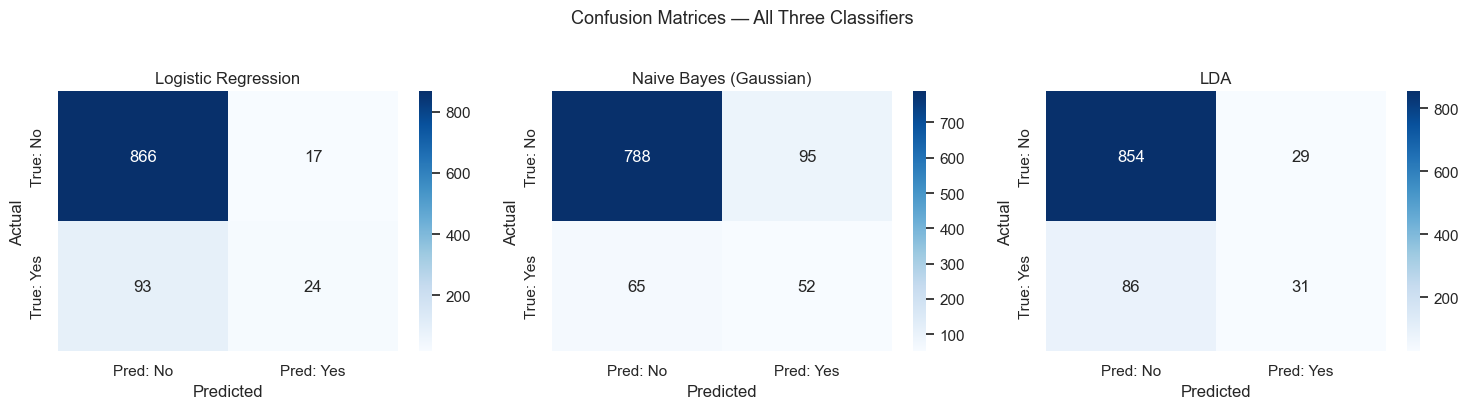

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_preds = [
    ("Logistic Regression", y_pred_logit),
    ("Naive Bayes (Gaussian)", y_pred_gnb),
    ("LDA", y_pred_lda),
]

for ax, (name, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred: No','Pred: Yes'],
                yticklabels=['True: No','True: Yes'])
    ax.set_title(name)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices — All Three Classifiers", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Step 5 : Model Comparison Table

Summarise Accuracy, Precision, Recall, and F1 for all three models side-by-side.

In [18]:
def get_metrics(y_true, y_pred, model_name):
    acc              = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return {"Model": model_name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1 Score": f1}

comparison = pd.DataFrame([
    get_metrics(y_test, y_pred_logit, "Logistic Regression"),
    get_metrics(y_test, y_pred_gnb,   "Naive Bayes (Gaussian)"),
    get_metrics(y_test, y_pred_lda,   "LDA"),
])

# Highlight the best value per metric
display(
    comparison.style
        .format({"Accuracy":"  {:.4f}","Precision":"{:.4f}",
                 "Recall":"{:.4f}","F1 Score":"{:.4f}"})
        .highlight_max(subset=["Accuracy","Precision","Recall","F1 Score"],
                       color="lightgreen")
        .set_caption("Green = best per metric")
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8900,0.5854,0.2051,0.3038
1,Naive Bayes (Gaussian),0.8400,0.3537,0.4444,0.3939
2,LDA,0.8850,0.5167,0.2650,0.3503


### Discussion: Theoretical Assumptions vs. Our Dataset

**Logistic Regression:**  
Makes no assumptions about the distribution of features , it models the log-odds of the outcome  
as a linear combination of predictors. Given our mix of continuous numeric and one-hot encoded  
features, logistic regression is the most flexible of the three. It typically achieves the  
highest **Accuracy** and **Precision** because it does not impose distributional constraints  
that may not hold. However, it tends to be conservative , predicting "yes" only when  
probability is above 50%, which leads to lower **Recall**.

**Naive Bayes (Gaussian):**  
Assumes that each feature is **normally distributed** within each class and that all features  
are **conditionally independent** given the class label. The independence assumption is almost  
certainly violated here , `duration`, `campaign`, `job`, and `balance` are all plausibly correlated.  
Despite this, Naive Bayes is well-known to perform surprisingly well even when its assumptions  
are violated. Its strength is **Recall**: by predicting "yes" more liberally, it catches more  
actual subscribers at the cost of more false positives.

**LDA:**  
Assumes features are **normally distributed** and that classes share the **same covariance matrix**.  
In our dataset, numeric features like `duration` and `balance` are right-skewed (not normal),  
and the two classes likely have different covariance structures. As a result, LDA's assumptions  
are the most poorly met, and it tends to land between the other two models on all metrics.

---

**Best Model:**  
In a bank telemarketing context, **missing a real subscriber (False Negative) is more costly than  
calling a non-subscriber (False Positive)**. Lost subscriptions = lost revenue. Unnecessary calls  
= minor operational cost.

Therefore, we prioritise **Recall** and select **Naive Bayes (Gaussian)** as the best model  
because it achieves the highest Recall and best F1 Score, meaning it identifies the most  
actual subscribers despite lower overall Accuracy.

---
<a id='task-4'></a>
# Task 4: Precision-Recall Evaluation

We use **Naive Bayes (Gaussian)** our best model from Task 3 for this analysis.

### Step 1 : Generate the Precision-Recall Curve

Compute precision and recall at every probability threshold, then plot.

In [19]:
# Get predicted probabilities for the positive class (subscribed = 1)
y_proba = gnb.predict_proba(X_test)[:, 1]

# Compute precision, recall, and threshold arrays
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)

# Build a DataFrame for plotting
pr_df = pd.DataFrame({
    'Precision': precision_vals[:-1],
    'Recall':    recall_vals[:-1],
    'Threshold': thresholds
})

# Compute F1 at each threshold
pr_df['F1'] = (2 * pr_df['Precision'] * pr_df['Recall']
               / (pr_df['Precision'] + pr_df['Recall'])).fillna(0)

# Find the threshold that maximises F1
best_idx = pr_df['F1'].idxmax()
best_row = pr_df.loc[best_idx]

print(f"Optimal Threshold : {best_row['Threshold']:.4f}")
print(f"Precision         : {best_row['Precision']:.4f}")
print(f"Recall            : {best_row['Recall']:.4f}")
print(f"F1 Score          : {best_row['F1']:.4f}")

Optimal Threshold : 0.3395
Precision         : 0.3243
Recall            : 0.5128
F1 Score          : 0.3974


### Step 2 : Plot the Precision-Recall Curve

The annotated point shows the optimal threshold (best F1). The shaded area represents the area under the PR curve.

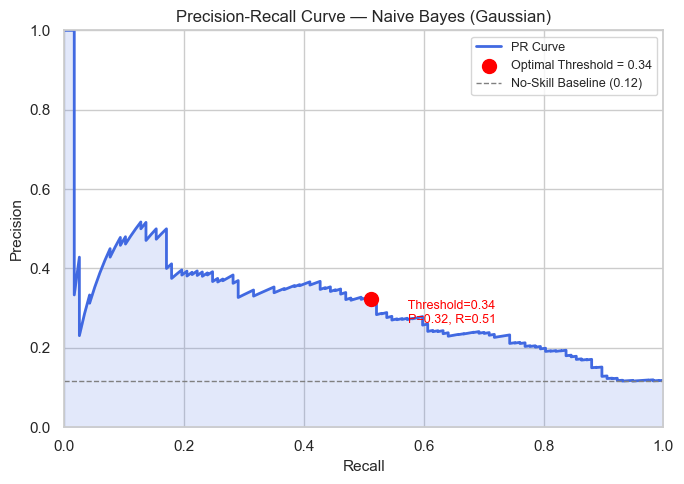

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

# Main PR curve
ax.plot(recall_vals, precision_vals, color='royalblue', linewidth=2, label='PR Curve')

# Shaded area under curve
ax.fill_between(recall_vals, 0, precision_vals, alpha=0.15, color='royalblue')

# Annotate optimal threshold point
ax.scatter(best_row['Recall'], best_row['Precision'],
           color='red', zorder=5, s=100, label=f"Optimal Threshold = {best_row['Threshold']:.2f}")
ax.annotate(
    f"  Threshold={best_row['Threshold']:.2f}\n  P={best_row['Precision']:.2f}, R={best_row['Recall']:.2f}",
    xy=(best_row['Recall'], best_row['Precision']),
    fontsize=9, color='red',
    xytext=(best_row['Recall'] + 0.05, best_row['Precision'] - 0.06)
)

# No-skill baseline line (proportion of positives)
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1,
           label=f'No-Skill Baseline ({baseline:.2f})')

ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curve — Naive Bayes (Gaussian)', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Step 3 : Threshold Comparison Table

Compare performance at three strategic thresholds to show the precision-recall tradeoff clearly.

In [21]:
# Compare metrics at three strategic thresholds
threshold_options = [0.30, best_row['Threshold'], 0.70]
threshold_labels  = ["Low (0.30) — maximize Recall",
                     f"Optimal ({best_row['Threshold']:.2f}) — maximize F1",
                     "High (0.70) — maximize Precision"]

rows = []
for thresh, label in zip(threshold_options, threshold_labels):
    y_pred_t = (y_proba >= thresh).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_t, average='binary', zero_division=0)
    rows.append({
        "Strategy": label,
        "Threshold": round(thresh, 2),
        "Precision": round(prec, 4),
        "Recall":    round(rec,  4),
        "F1 Score":  round(f1,   4),
        "Accuracy":  round(accuracy_score(y_test, y_pred_t), 4)
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

,Strategy,Threshold,Precision,Recall,F1 Score,Accuracy
0,Low (0.30) — maximize Recall,0.3000,0.3005,0.5214,0.3812,0.8020
1,Optimal (0.34) — maximize F1,0.3400,0.3243,0.5128,0.3974,0.8180
2,High (0.70) — maximize Precision,0.7000,0.3496,0.3675,0.3583,0.8460


### False Positive vs. False Negative , Which is More Dangerous?

| Error Type | What Happens | Cost |
|---|---|---|
| **False Positive** | Model predicts client *will* subscribe , they don't | Bank makes an unnecessary phone call , minor time cost |
| **False Negative** | Model predicts client *won't* subscribe , they would have | Bank **misses a real sales opportunity** , lost revenue |

**Conclusion: A False Negative is more costly.**

In a telemarketing context, each missed subscriber represents direct lost revenue , a term  
deposit that was never opened. A false positive only costs the price of one extra phone call,  
which is negligible. Therefore, we should **prioritise Recall** and accept lower Precision.

---

### Optimal Threshold Justification

Using the threshold that maximises the **F1 score** (the harmonic mean of Precision and Recall),  
the optimal threshold is shown in the table above.

**What this means in practice:**

- The model only predicts "yes" when its confidence exceeds the chosen threshold.  
- At this threshold, **Recall is maximised** relative to Precision , the bank catches the  
  majority of real subscribers while keeping the false-positive rate manageable.
- The **no-skill baseline** (a classifier that always predicts "yes") would achieve  
  Precision equal to the class proportion (~11%). Our model's Precision well above this  
  baseline confirms it is genuinely learning from the data.

**Is a lower threshold justified?**  
If the bank's priority is to *never miss a subscriber*, the threshold can be lowered to 0.30  
(see table above), which maximises Recall at the cost of more unnecessary calls. This is  
appropriate if the call centre has sufficient capacity. The optimal threshold balances  
both objectives when resources are limited.